
[GraphBLAS](https://graphblas.org/) is a framework for expressing graph algorithms through sparse linear algebra. A graph is represented as a sparse adjacency matrix, with nodes represented as sparse vectors. It emerged from a realization that many graph algorithms are fundamentally sparse linear algebra algorithms, and many graph operations could be expressed as matrix operations. For example, many graph algorithms can be understood as variations on the frontier expansion pattern used by breadth-first search (BFS). In GraphBLAS, each BFS step can be performed efficiently as a sparse vector–matrix multiplication, which expands the current frontier to its neighboring nodes. This makes GraphBLAS an efficient way to run algorithms on large, sparse graphs, while also making it easier to take advantage of parallel computation.

The name *GraphBLAS* reflects its goal of doing for graph algorithms what BLAS (Basic Linear Algebra Subprogram) and LAPACK (Linear Algebra PACKage) do for numerical computing. Libraries like NumPy provide a convenient, high-level interface that relies on highly optimized linear algebra subroutines for computationally intensive workloads. Most users rarely interact with BLAS/LAPACK directly, but they nonetheless serve as foundational pieces of the scientific computing ecosystem. GraphBLAS aims to play a similar role for graph analysis, by providing an efficient sparse matrix and vector backend that higher-level libraries can build on. For example, NetworkX can dispatch supported algorithms to a GraphBLAS backend, which allows users to keep working with the familiar NetworkX API while GraphBLAS performs the underlying computation more efficiently.

We begin by introducing the breadth first search algorithm. A simple implementation is provided, as well as a  step-by-step walkthrough of how the search frontier expands over time. Then we'll look at how BFS is framed within GraphBLAS. Finally, we'll demonstrate how to use the GraphBLAS backend from NetworkX, and compare the performance of a few common graph algorithms with and without backend acceleration.


<br>





### **Breadth-First Search**

If you've taken an introductory Computer Science course or spent time working with graphs, you've encountered Breadth-First Search (BFS). It is one of the simplest graph traversal algorithms, yet it serves as the foundation for dozens of more sophisticated algorithms including shortest paths, connected components, centrality measures, and even finds use graph neural networks.

BFS explores a graph one "layer" at a time. Beginning from a source node, it first visits every immediate neighbor. Only after exhausting those neighbors does it move on to nodes two hops away, then three hops away, and so on. BFS expands outward like ripples on a pond. Contrast BFS with Depth-First Search (DFS), which dives as deeply as possible before backtracking. 

Because BFS processes nodes in increasing distance from the source, the first time it reaches the target, the stored path is guaranteed to be a shortest path in an unweighted graph.

For example, consider the simple graph below:

```text
        A
      / | \
     B  C  D
    / \    |
   E   F   G
      / \
     H   I
```

Starting from node A, the visitation order is:

```text
A

B C D

E F G

H I
```

Every node one edge away from A is visited before any node two edges away. This is what makes BFS especially useful for finding shortest paths in unweighted graphs.

Note that BFS does not properly handle weighted graphs because it searches by the number of edges in a path, not by the total cost of those edges. It assumes every edge has the same cost, so the first time it reaches a node, it treats that route as the shortest. For nonnegative weighted graphs, Dijkstra's algorithm can be used since it explores nodes according to the lowest accumulated cost instead of hop count.

The heart of BFS is a queue, which is a First-In First-Out (FIFO) data structure. Whenever a new node is discovered, it is placed at the back of the queue. Whenever we're ready to explore another node, we remove it from the front of the queue. This guarantees that nodes are explored in increasing order of their distance from the source. This will be clearly demonstrated in the time evolution plot later in this section. 

<div style="text-align:center;">
    <img src="bfs.png" width="60%">
    <figcaption><em>BFS pseudo code</em></figcaption>
</div>

<br>

Lets create a simple undirected graph to demonstrate BFS:




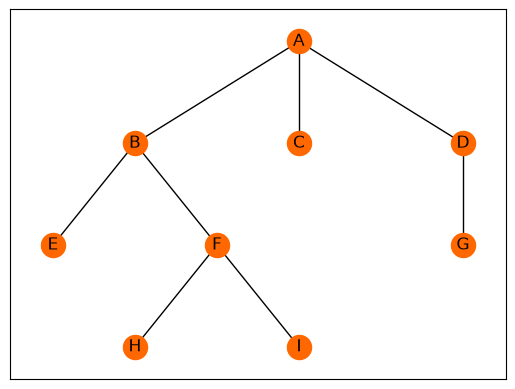

In [1]:

import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

edges = [
    ("A","B"),
    ("A","C"),
    ("A","D"),
    ("B","E"),
    ("B","F"),
    ("D","G"),
    ("F","H"),
    ("F","I"),
]

# Specify positions for fixed layout. 
pos = {
    "A": (0, 3), "B": (-2, 2), "C": (0, 2), "D": (2, 2), "E": (-3, 1),
    "F": (-1, 1), "G": (2, 1), "H": (-2, 0), "I": (0, 0),
}

G.add_edges_from(edges)

nx.draw_networkx(
    G,
    pos,
    node_color="#ff6700",
)



<br>

In the next cell, we implement BFS to traverse a graph starting from a specified node. All of a node's neighbors are explored before moving on to the next level of nodes, which pushes the frontier forward. The function returns a list representing the visitation order starting from any node in the graph:


In [2]:

from collections import deque

def bfs(graph, start):

    # Visited nodes.
    visited = {start}

    # Initialize queue with the starting node.
    q = deque([start])

    # List to store the order of visited nodes.
    order = []

    while q:

        # Pop the leftmost node from the queue.
        node = q.popleft()
        order.append(node)

        for neighbor in graph.neighbors(node):

            if neighbor not in visited:

                visited.add(neighbor)
                q.append(neighbor)

    return order


# Generate visitation paths for each node. 
print("BFS traversal order starting from A:", bfs(G, "A"))
print("BFS traversal order starting from B:", bfs(G, "B"))
print("BFS traversal order starting from C:", bfs(G, "C"))
print("BFS traversal order starting from D:", bfs(G, "D"))
print("BFS traversal order starting from E:", bfs(G, "E"))
print("BFS traversal order starting from F:", bfs(G, "F"))
print("BFS traversal order starting from G:", bfs(G, "G"))
print("BFS traversal order starting from H:", bfs(G, "H"))
print("BFS traversal order starting from H:", bfs(G, "I"))


BFS traversal order starting from A: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']
BFS traversal order starting from B: ['B', 'A', 'E', 'F', 'C', 'D', 'H', 'I', 'G']
BFS traversal order starting from C: ['C', 'A', 'B', 'D', 'E', 'F', 'G', 'H', 'I']
BFS traversal order starting from D: ['D', 'A', 'G', 'B', 'C', 'E', 'F', 'H', 'I']
BFS traversal order starting from E: ['E', 'B', 'A', 'F', 'C', 'D', 'H', 'I', 'G']
BFS traversal order starting from F: ['F', 'B', 'H', 'I', 'A', 'E', 'C', 'D', 'G']
BFS traversal order starting from G: ['G', 'D', 'A', 'B', 'C', 'E', 'F', 'H', 'I']
BFS traversal order starting from H: ['H', 'F', 'B', 'I', 'A', 'E', 'C', 'D', 'G']
BFS traversal order starting from H: ['I', 'F', 'B', 'H', 'A', 'E', 'C', 'D', 'G']


<br>

Watching BFS unfold is much more informative than simply seeing the final node ordering:


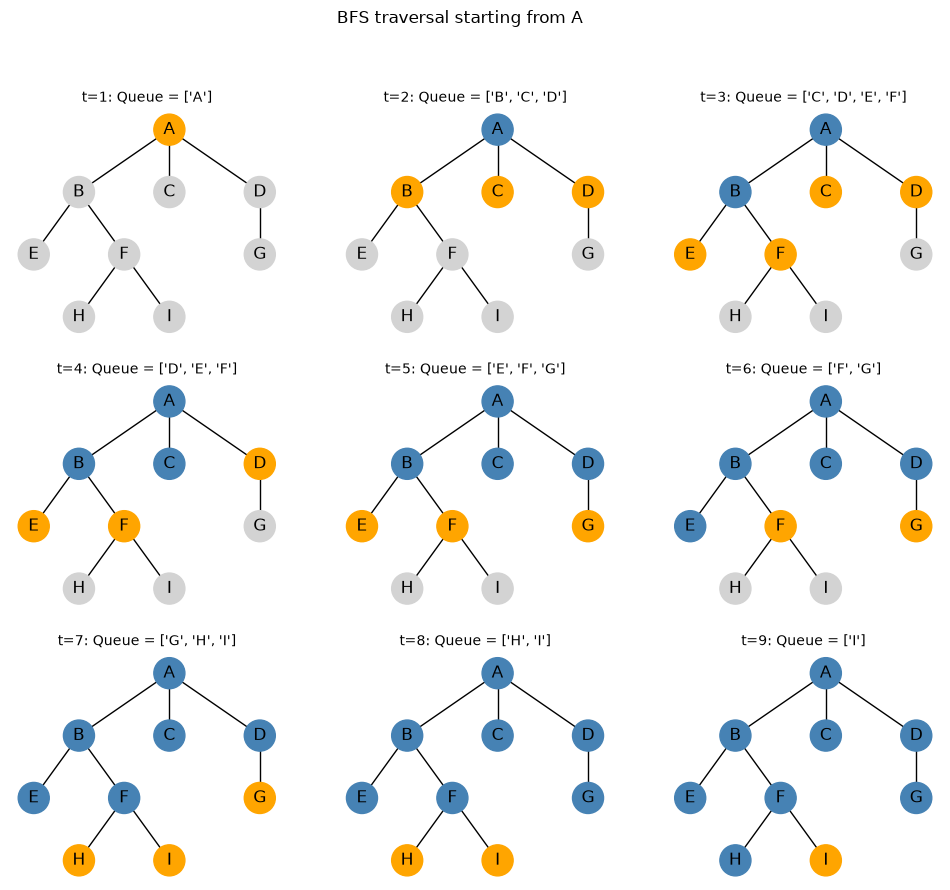

In [3]:

# Capture visitation order as well as queue state at each step of
# the BFS traversal.
start = "A"
visited = {start}
queue = deque([start])
history = []

while queue:
    history.append((list(queue), set(visited)))
    node = queue.popleft()
    for nbr in G.neighbors(node):
        if nbr not in visited:
            visited.add(nbr)
            queue.append(nbr)



fig, axes = plt.subplots(3, 3, figsize=(12,10))

axes = axes.ravel()

for ii, (ax, (queue_state, visited)) in enumerate(zip(axes, history), start=1):

    colors = []

    for node in G.nodes():

        if node in queue_state:
            colors.append("orange")
        elif node in visited:
            colors.append("steelblue")
        else:
            colors.append("lightgray")

    nx.draw_networkx(
        G,
        pos,
        node_color=colors,
        ax=ax,
        with_labels=True,
        node_size=500
    )

    ax.set_title(f"t={ii}: Queue = {queue_state}", fontsize=10)
    ax.axis("off")

fig.suptitle(f"BFS traversal starting from {start}", fontsize=12)
plt.show()



<br>

Start with the upper-left facet, and navigate left-to-right, top-to-bottom. In each snapshot:

- Blue nodes have been visited.
- Orange nodes are waiting in the queue.
- Gray nodes have not been discovered.

Referring to the snapshot at row 2 column 1 (using 1-based indexing), where the queue state is `['D', 'E', 'F']`: Since a queue is used, BFS is guaranteed to visit `'D'` prior to `'E'` and `'F'` (`'D'` will be ahead of `'E'` and `'F'` in `q`).


Our current BFS implementation gives us the visitation order from any starting point. It can be adapted to instead return the shortest unweighted path between two nodes (`bfs_shortest_path`), or the shortest path between a starting node and all other nodes (`single_source_shortest_path`):



In [4]:

def bfs_shortest_path(graph, start, target):
    """
    Determine the shortest path from start to target via BFS.
    """
    # Populate q with 2-tuple as (node, path) where path is the path
    # taken to reach node.
    q = deque([(start, [start])])

    # Keep track of visited nodes to avoid cycles.
    visited = {start}

    while q:

        node, pth = q.popleft()

        if node == target:
            return pth

        for neighbor in graph.neighbors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                q.append((neighbor, pth + [neighbor]))

    return None


def single_source_shortest_paths(graph, start):
    """
    Determine the shortest path between starting node and all other nodes 
    in the graph.
    """
    return {
        target: bfs_shortest_path(graph, start, target) for target in graph.nodes()
    }


print("All pairs shortest path starting from A:")
single_source_shortest_paths(G, start="A")



All pairs shortest path starting from A:


{'A': ['A'],
 'B': ['A', 'B'],
 'C': ['A', 'C'],
 'D': ['A', 'D'],
 'E': ['A', 'B', 'E'],
 'F': ['A', 'B', 'F'],
 'G': ['A', 'D', 'G'],
 'H': ['A', 'B', 'F', 'H'],
 'I': ['A', 'B', 'F', 'I']}

<br>

BFS has a time complexity of $O(V + E)$, where $V$ is the number of vertices and $E$ is the number of edges in the graph. Even though the algorithm contains a nested loop, each vertex is added to the queue and visited at most once, and each edge is examined at most once as the algorithm explores the neighbors of each vertex. As a result, the total amount of work grows linearly with the size of the graph rather than quadratically. This makes BFS highly efficient for traversing large, sparse graphs and is one of the reasons it serves as the foundation for many other graph algorithms.

<br>

### **GraphBLAS**

GraphBLAS emerged from a realization that many graph algorithms are fundamentally sparse linear algebra algorithms, and many graph operations could be expressed as matrix operations. For example, BFS can be implemented as sparse vector-matrix multiplication. One sparse vector-matrix multiplication computes one BFS frontier expansion, and repeated multiplications produce the full BFS traversal.

You can think of GraphBLAS as being to graph analytics what BLAS is to machine learning: Most machine learning practitioners never call BLAS directly, but almost everything relies on it. Similarly, graph practitioners may never call GraphBLAS directly, but many graph systems can be built on top of it. The goal was to create a standardized set of sparse linear algebra primitives from which most graph algorithms could be constructed. 


<div style="text-align:center;">
    <img src="gb01.png" width="65%">
    <figcaption><em>Single step of BFS via sparse vector-matrix multiply.</em></figcaption>
</div>

<br>

A number of common graph algorithms can be framed as sparse linear algebra algorithms:

- BFS (sparse vector-matrix multiplication)
- PageRank (iterative matrix-vector multiplication)
- Triangle counting (sparse matrix multiplication)
- Connected components (sparse matrix operations on special semirings)

Another GraphBLAS innovation is the use of *semirings*. In ordinary matrix multiplication, the operations are multiplication and addition. But for something like BFS, we care more about about reachability than products and sums. GraphBLAS generalizes matrix multiplication so it is possible to substitute `AND` for multiplication and `OR` for addition. This allows the same sparse matrix multiplication engine to solve completely different graph problems.


#### **Expressing BFS as Matrix–Vector Multiplication**

We can demonstrate BFS using an ordinary dense adjacency matrix and standard vector–matrix multiplication. The dense version makes the mechanics easy to see, although a GraphBLAS implementation would store the matrix sparsely and use specialized logical operations rather than performing unnecessary calculations on all the zeros.

Starting with the 9-node graph `G` from before, we obtain the adjacency matrix representation:


In [5]:

import numpy as np
import networkx as nx

nodes = ["A", "B", "C", "D", "E", "F", "G", "H", "I"]

M = nx.to_numpy_array(
    G,
    nodelist=nodes,
    dtype=int,
)

print(f"Adjacency matrix for G:\n\n{M}")



Adjacency matrix for G:

[[0 1 1 1 0 0 0 0 0]
 [1 0 0 0 1 1 0 0 0]
 [1 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 1 1]
 [0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0 0]]



Each row and column corresponds to a node. An entry $M_{ij}=1$ means that node $i$ is connected to node $j$; an entry of 0 means there is no edge. Because $G$ is an undirected graph, the matrix is symmetric.

Suppose BFS begins at node A. Represent the current search frontier as a row vector `f0`. A value of 1 means that a node is in the frontier.

After multiplying `f0` with adjacency matrix `M`, we get a vector the same length as the original with 1s representing immediate neighbors of A (B, C, D) and 0s elsewhere. `f1` represents the next frontier in the search. 

In [6]:

# Sparse representation of starting node. 
f0 = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0])

# Multiply the starting node by the adjacency matrix to get the next frontier.
f1 = f0 @ M

print(f"Starting point (f0): {f0}")
print(f"Next frontier  (f1): {f1}")


Starting point (f0): [1 0 0 0 0 0 0 0 0]
Next frontier  (f1): [0 1 1 1 0 0 0 0 0]




We can expand to the next frontier with second vector-matrix multiply:

In [7]:

f2 = f1 @ M

print(f"Next frontier (f2): {f2}")


Next frontier (f2): [3 0 0 0 1 1 1 0 0]


<br>

The result says that the current frontier connects back to A three times and also reaches E, F, and G. The value 3 at A is a path count: each of B, C, and D connects back to A.

BFS must prevent previously visited nodes from returning to the frontier. After removing A, B, C, and D, the new frontier `f2` becomes `[0, 0, 0, 0, 1, 1, 1, 0, 0]`. This represents the second layer of BFS (E, F, G).  Another vector matrix multiply:

In [8]:

f2 = np.array([0, 0, 0, 0, 1, 1, 1, 0, 0])

f3 = f2 @ M

print(f"Next frontier (f3): {f3}")


Next frontier (f3): [0 2 0 1 0 0 0 1 1]



Removing already visited nodes B and D, we're left with `[0, 0, 0, 0, 0, 0, 0, 1, 1]`, which gives us the third BFS layer (H, I). 

One more multiplication only leads back to F, which has already been visited, so the next frontier is empty and the search ends. 


In [9]:
f3 = np.array([0, 0, 0, 0, 0, 0, 0, 1, 1])

f4 = f3 @ M

print(f"Next frontier (f4): {f4}")


Next frontier (f4): [0 0 0 0 0 2 0 0 0]


The visitation order turns out to be exactly what we found using the queue-based BFS implementation:

```
Depth 0: ['A']
Depth 1: ['B', 'C', 'D']
Depth 2: ['E', 'F', 'G']
Depth 3: ['H', 'I']
```

GraphBLAS expresses these same ideas using sparse vectors, sparse matrices, masks, and a Boolean semiring. The sparse representation is far more efficient for large graphs because it stores and processes only existing edges and active frontier entries rather than all the zeros in a dense adjacency matrix.

This post only scratches the surface of GraphBLAS. For more on the theoretical underpinnings of the library and the linear algebraic framing of graph algorithms, check out *Graph Algorithms in the Language of Linear Algebra*.


<div style="text-align:center;">
    <img src="book.png" width="37%">
    <figcaption><em>Excellent resource highlighting the ideas and insights that came to be GraphBLAS.</em></figcaption>
</div>


#### **Benchmarking**

To demonstrate the performance gains from using the GraphBLAS backend, we benchmark three algorithms against native NetworkX across graphs of increasing size:

- **triangles**: Counts the number of triangles that each node participates in. A triangle is a set of three nodes where every node is connected to the other two.

- **pagerank**: Measures the importance of each node based on the number and importance of the nodes linking to it. 

- **all_pairs_shortest paths**: Computes the shortest path distance between every pair of nodes in a graph.

In the benchmarking code, the line `G1 = ga.Graph.from_networkx(G0)` transforms the NetworkX graph to a GraphBLAS representation. This is intentionally done outside of the call to `timeit`, since our goal is to compare the algorithm implementations themselves, which is similar to a realistic workflow where a graph is converted once and then reused for multiple analyses. It is not a fair measure of the total cost of a one-off call starting from a NetworkX graph, because that workflow includes conversion overhead. In the *NextworkX Backends* section, we'll perform the same comparison without the explicit conversion to GraphBLAS ahead of time, effectively including the conversion cost in the benchmark. I believe this dual benchmarking serves as a good demonstration of both the computational advantage of GraphBLAS as well as the cost required to access it.

We start with the ahead-of-time conversion. Because `G1` is already a GraphBLAS graph, NetworkX automatically sends supported calls to that backend. 

Ensure the graphblas-algorithms library is installed:




```sh
$ python -m pip install graphblas-algorithms
```

In [ ]:
"""
Compare performance of NetworkX and GraphBLAS on three algorithms with
ahead-of-time graph conversion. 
"""
import timeit
import pandas as pd
import graphblas_algorithms as ga

nx.config.warnings_to_ignore.add("cache")

# Graph sizes. 
node_counts = [500, 1_000, 2_500, 5_000, 10_000, 15_000, 20_000, 25_000]

# Keep average degree constant as node count grows. 
target_degree = 15

# Timing runs per comparison.
n_runs = 5

# Timing results.
shortest_paths, triangles, pagerank = [], [], []

# Warmup both implementations to handle one-time initialization outside of the 
# timing loop. This is important for GraphBLAS, which has one-time initialization 
# overhead.
G_warm_nx = nx.erdos_renyi_graph(100, 0.05, seed=1)
G_warm_gb = ga.Graph.from_networkx(G_warm_nx)
nx.pagerank(G_warm_gb)
nx.pagerank(G_warm_nx)
nx.triangles(G_warm_gb)
nx.triangles(G_warm_nx)
dict(nx.all_pairs_shortest_path_length(G_warm_gb))
dict(nx.all_pairs_shortest_path_length(G_warm_nx))


for n_nodes in node_counts:

    p = target_degree / (n_nodes - 1)

    # Create random graph with n_nodes and probability p of edge creation.
    G0 = nx.erdos_renyi_graph(
        n=n_nodes,
        p=p,
        seed=516,
    )

    # Convert to GraphBLAS graph. Do this outside of the timing loop to avoid 
    # including the conversion time in the benchmark.
    G1 = ga.Graph.from_networkx(G0)

    # Pagerank comparison.
    t_nx_pagerank = timeit.timeit(
        lambda: nx.pagerank(G0),
        number=n_runs,
    ) / n_runs

    t_gb_pagerank = timeit.timeit(
        lambda: nx.pagerank(G1),
        number=n_runs,
    ) / n_runs

    pagerank.append({
        "nodes": n_nodes,
        "edges": G0.number_of_edges(),
        "nx_secs": t_nx_pagerank,
        "gb_secs": t_gb_pagerank,
        "speedup": t_nx_pagerank / t_gb_pagerank,
    })
    
    # Triangles comparison.
    t_nx_triangles = timeit.timeit(
            lambda: nx.triangles(G0),
            number=n_runs,
        ) / n_runs
    
    t_gb_triangles = timeit.timeit(
        lambda: nx.triangles(G1),
        number=n_runs,
    ) / n_runs

    triangles.append({
        "nodes": n_nodes,
        "edges": G0.number_of_edges(),
        "nx_secs": t_nx_triangles,
        "gb_secs": t_gb_triangles,
        "speedup": t_nx_triangles / t_gb_triangles,
    })

    # Shortest path comparison.
    t_nx_shortest_path = timeit.timeit(
        lambda: dict(nx.all_pairs_shortest_path_length(G0)),
        number=n_runs,
    ) / n_runs

    t_gb_shortest_path = timeit.timeit(
        lambda: dict(nx.all_pairs_shortest_path_length(G1)),
        number=n_runs,
    ) / n_runs

    shortest_paths.append({
        "nodes": n_nodes,
        "edges": G0.number_of_edges(),
        "nx_secs": t_nx_shortest_path,
        "gb_secs": t_gb_shortest_path,
        "speedup": t_nx_shortest_path / t_gb_shortest_path,
    })

    print(f"Completed benchmark for n_nodes = {n_nodes}")


pagerank_results = pd.DataFrame(pagerank)
triangles_results = pd.DataFrame(triangles)
shortest_path_results = pd.DataFrame(shortest_paths)


Completed benchmark for n_nodes = 500
Completed benchmark for n_nodes = 1000
Completed benchmark for n_nodes = 2500
Completed benchmark for n_nodes = 5000
Completed benchmark for n_nodes = 10000
Completed benchmark for n_nodes = 15000
Completed benchmark for n_nodes = 20000
Completed benchmark for n_nodes = 25000



<br>

Lets visualize the results. The table on the right gives the speedup of GraphBLAS over NetworkX using ahead-of-time conversion:

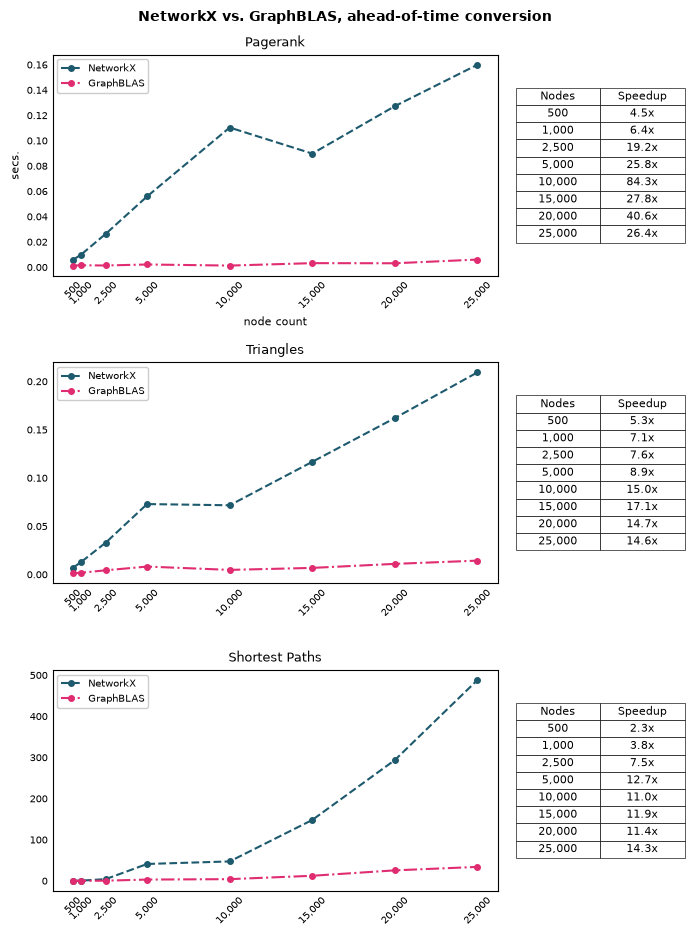

In [11]:
"""
Visualize benchmark results.
"""
import matplotlib.pyplot as plt


nx_color = "#1e5a6e"
gb_color = "#E02C70"


def add_speedup_table(axis, results):
    """
    Add speedup as a function of node count to the given axis.
    """
    speedup = results.get(
        "speedup",
        results["nx_secs"] / results["gb_secs"],
    )

    table_data = [
        [f"{nodes:,}", f"{value:.1f}x"]
        for nodes, value in zip(node_counts, speedup)
    ]

    table = axis.table(
        cellText=table_data,
        colLabels=["Nodes", "Speedup"],
        cellLoc="center",
        colLoc="center",
        bbox=[1.04, 0.15, 0.38, 0.70],
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)

    for cell in table.get_celld().values():
        cell.set_linewidth(0.5)
        cell.set_alpha(0.9)



fig, ax = plt.subplots(3, 1, figsize=(7, 9.5), tight_layout=True)

# Adjust facets to place speedup table outside of the plot area.
fig.subplots_adjust(
    left=0.10, right=0.72, top=0.94, bottom=0.07, hspace=0.45,
)

# Pagerank results.
ax[0].set_title("Pagerank", fontsize=9, loc="center", weight="normal")
ax[0].plot(
    node_counts, pagerank_results["nx_secs"], color=nx_color, 
    linewidth=1.5, linestyle="--", marker="o", markersize=4, 
    label="NetworkX"
)
ax[0].plot(
    node_counts, pagerank_results["gb_secs"], color=gb_color, 
    linewidth=1.5, linestyle="-.", marker="o", markersize=4, 
    label="GraphBLAS"
)
ax[0].set_xlabel("node count", fontsize=8, weight="normal")
ax[0].set_ylabel("secs.", fontsize=8, weight="normal")
ax[0].set_xticks(node_counts)
ax[0].set_xticklabels([f"{ii:,.0f}" for ii in node_counts])
ax[0].tick_params(axis="x", which="major", direction="in", labelsize=7, rotation=45)
ax[0].tick_params(axis="y", which="major", direction="in", labelsize=7)
ax[0].xaxis.set_ticks_position("none")
ax[0].yaxis.set_ticks_position("none")
# ax[0].grid(True)
ax[0].legend(
    loc="upper left", fancybox=True, framealpha=1, fontsize="x-small"
)
add_speedup_table(ax[0], pagerank_results)


# Triangles results.
ax[1].set_title("Triangles", fontsize=9, loc="center", weight="normal")
ax[1].plot(
    node_counts, triangles_results["nx_secs"], color=nx_color, 
    linewidth=1.5, linestyle="--", marker="o", markersize=4, 
    label="NetworkX"
)
ax[1].plot(
    node_counts, triangles_results["gb_secs"], color=gb_color, 
    linewidth=1.5, linestyle="-.", marker="o", markersize=4, 
    label="GraphBLAS"
)
ax[1].set_xticks(node_counts)
ax[1].set_xticklabels([f"{ii:,.0f}" for ii in node_counts])
ax[1].tick_params(axis="x", which="major", direction="in", labelsize=7,rotation=45)
ax[1].tick_params(axis="y", which="major", direction="in", labelsize=7)
ax[1].xaxis.set_ticks_position("none")
ax[1].yaxis.set_ticks_position("none")
# ax[1].grid(True)
ax[1].legend(
    loc="upper left", fancybox=True, framealpha=1, fontsize="x-small"
)
add_speedup_table(ax[1], triangles_results)

# Shortest paths results.
ax[2].set_title("Shortest Paths", fontsize=9, loc="center", weight="normal")
ax[2].plot(
    node_counts, shortest_path_results["nx_secs"], color=nx_color, 
    linewidth=1.5, linestyle="--", marker="o", markersize=4, 
    label="NetworkX"
)
ax[2].plot(
    node_counts, shortest_path_results["gb_secs"], color=gb_color, 
    linewidth=1.5, linestyle="-.", marker="o", markersize=4, 
    label="GraphBLAS"
)
ax[2].set_xticks(node_counts)
ax[2].set_xticklabels([f"{ii:,.0f}" for ii in node_counts])
ax[2].tick_params(axis="x", which="major", direction="in", labelsize=7, rotation=45)
ax[2].tick_params(axis="y", which="major", direction="in", labelsize=7)
ax[2].xaxis.set_ticks_position("none")
ax[2].yaxis.set_ticks_position("none")
# ax[2].grid(True)
ax[2].legend(
    loc="upper left", fancybox=True, framealpha=1, fontsize="x-small"
)
add_speedup_table(ax[2], shortest_path_results)

plt.suptitle(
    "NetworkX vs. GraphBLAS, ahead-of-time conversion", 
    fontsize=10, 
    weight="bold"
)

plt.show()



Across five timing trials with the graphs converted ahead-of-time, GraphBLAS outperformed native NetworkX for every algorithm and graph size. PageRank showed the largest but most variable gains, settling between roughly 25-40x at larger sizes. Triangle counting produced steadier improvements, rising from about 5x on the smallest graph to approximately ~15x from 10,000 nodes onward. All-pairs shortest paths showed the clearest scaling pattern: the speedup increased from 2x at 500 nodes to 14x at 25,000 nodes, where native NetworkX required nearly 500 seconds compared with roughly 35 seconds for GraphBLAS. The results show that once conversion overhead is removed, GraphBLAS provides substantial acceleration, with more pronounced benefit as the computational workload grows.


#### **Backends**

A backend is an alternative computational engine that performs an algorithm behind the scenes while allowing the user to keep working through the same high-level NetworkX interface. Many NetworkX algorithms are decorated with `@nx._dispatchable` (see, for example [here](https://networkx.org/documentation/stable/_modules/networkx/algorithms/centrality/eigenvector.html#eigenvector_centrality)), which marks them as eligible for execution by one of the alternative backends. When GraphBLAS is explicitly requested, NetworkX converts the graph as needed and calls the corresponding GraphBLAS implementation. Otherwise, calls involving ordinary NetworkX graphs use the library's native Python implementation.

Besides GraphBLAS, two of the most useful NetworkX backends are cuGraph and nx-parallel:

The cuGraph backend runs supported graph algorithms on NVIDIA GPUs using RAPIDS cuGraph (discussed at length in the last post). It is especially useful for very large graphs and computationally expensive algorithms like PageRank, centrality measures, shortest paths, and community detection. The potential speedups can be substantial, but it requires NVIDIA GPUs, and moving a graph onto the GPU introduces conversion and data transfer overhead.

The nx-parallel backend keeps the computation on the CPU but divides certain algorithms into chunks and runs them across multiple cores. It is most useful for algorithms that naturally break into independent pieces. 

When you explicitly request GraphBLAS but GraphBLAS does not implement the function in question, NetworkX generally raises an exception rather than silently using native NetworkX. Similarly, when the input is already a GraphBLAS graph, fallback to native NetworkX is disabled by default. You can enable fallback to NetworkX with:

```python
nx.config.fallback_to_nx = True
```

Setting this allows NetworkX to convert the backend graph back into a regular NetworkX graph and run the native implementation. Note that this conversion may be expensive for large graphs.

The simplest approach is to specify `backend="graphblas"` in a supported NetworkX function. NetworkX converts the graph to the backend representation and dispatches the computation to GraphBLAS. For this benchmark, we do not convert the graph to a GraphBLAS representation ahead-of-time: The original NetworkX graph is passed into each function, specifying the `backend="graphblas"`, so the conversion happens within each function invocation and is reflected in the timing results. 


In [ ]:
"""
Compare performance of NetworkX and GraphBLAS on three algorithms without
ahead-of-time graph conversion. 
"""
import timeit
import pandas as pd
import graphblas_algorithms as ga

nx.config.warnings_to_ignore.add("cache")


# Timing results.
shortest_paths, triangles, pagerank = [], [], []

for n_nodes in node_counts:

    p = target_degree / (n_nodes - 1)

    # Create random graph with n_nodes and probability p of edge creation.
    G = nx.erdos_renyi_graph(
        n=n_nodes,
        p=p,
        seed=516,
    )

    # Centrality comparison.
    t_nx_pagerank = timeit.timeit(
        lambda: nx.pagerank(G),
        number=n_runs,
    ) / n_runs

    t_gb_pagerank = timeit.timeit(
        lambda: nx.pagerank(G, backend="graphblas"),
        number=n_runs,
    ) / n_runs

    pagerank.append({
        "nodes": n_nodes,
        "edges": G.number_of_edges(),
        "nx_secs": t_nx_pagerank,
        "gb_secs": t_gb_pagerank,
        "speedup": t_nx_pagerank / t_gb_pagerank,
    })

    # Triangles comparison.
    t_nx_triangles = timeit.timeit(
            lambda: nx.triangles(G),
            number=n_runs,
        ) / n_runs
    
    t_gb_triangles = timeit.timeit(
        lambda: nx.triangles(G, backend="graphblas"),
        number=n_runs,
    ) / n_runs

    triangles.append({
        "nodes": n_nodes,
        "edges": G.number_of_edges(),
        "nx_secs": t_nx_triangles,
        "gb_secs": t_gb_triangles,
        "speedup": t_nx_triangles / t_gb_triangles,
    })

    # Shortest path comparison.
    t_nx_shortest_path = timeit.timeit(
        lambda: dict(nx.all_pairs_shortest_path_length(G)),
        number=n_runs,
    ) / n_runs

    t_gb_shortest_path = timeit.timeit(
        lambda: dict(nx.all_pairs_shortest_path_length(G, backend="graphblas")),
        number=n_runs,
    ) / n_runs

    shortest_paths.append({
        "nodes": n_nodes,
        "edges": G.number_of_edges(),
        "nx_secs": t_nx_shortest_path,
        "gb_secs": t_gb_shortest_path,
        "speedup": t_nx_shortest_path / t_gb_shortest_path,
    })

    print(f"Completed benchmark for n_nodes = {n_nodes}")


pagerank_results = pd.DataFrame(pagerank)
triangles_results = pd.DataFrame(triangles)
shortest_path_results = pd.DataFrame(shortest_paths)


Completed benchmark for n_nodes = 500
Completed benchmark for n_nodes = 1000
Completed benchmark for n_nodes = 2500
Completed benchmark for n_nodes = 5000
Completed benchmark for n_nodes = 10000
Completed benchmark for n_nodes = 15000
Completed benchmark for n_nodes = 20000
Completed benchmark for n_nodes = 25000



For this set of exhibits, the table to the right represents the speedup of GraphBLAS over NetworkX without ahead-of-time conversion:

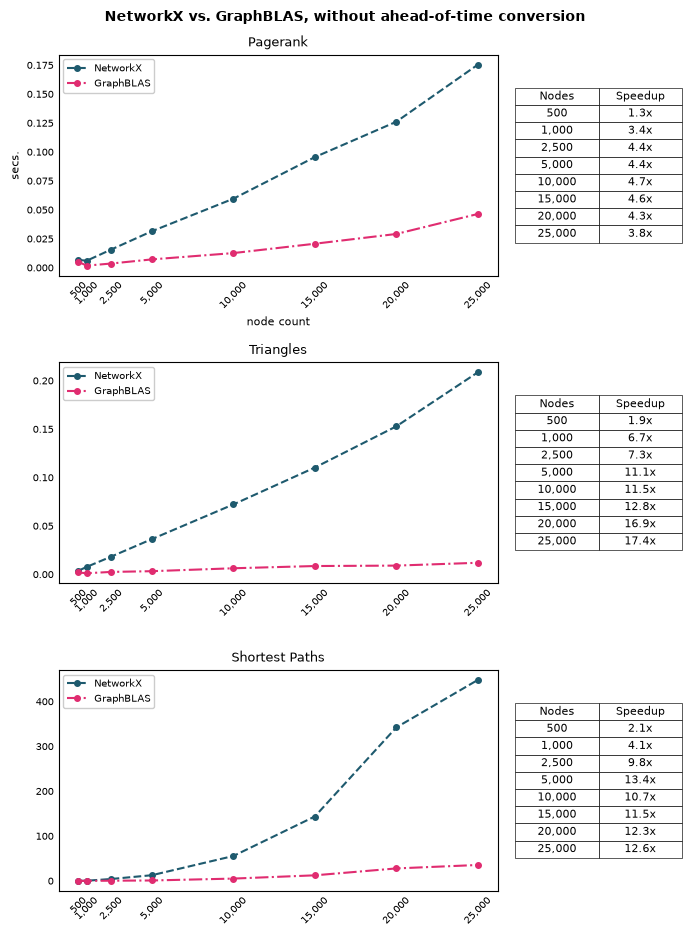

In [13]:
"""
Visualize benchmark without ahead-of-time conversion.
"""

nx_color = "#1e5a6e"
gb_color = "#E02C70"


fig, ax = plt.subplots(3, 1, figsize=(7, 9.5), tight_layout=True)

# Adjust facets to place speedup table outside of the plot area.
fig.subplots_adjust(
    left=0.10, right=0.72, top=0.94, bottom=0.07, hspace=0.45,
)

# Pagerank results.
ax[0].set_title("Pagerank", fontsize=9, loc="center", weight="normal")
ax[0].plot(
    node_counts, pagerank_results["nx_secs"], color=nx_color, 
    linewidth=1.5, linestyle="--", marker="o", markersize=4, 
    label="NetworkX"
)
ax[0].plot(
    node_counts, pagerank_results["gb_secs"], color=gb_color, 
    linewidth=1.5, linestyle="-.", marker="o", markersize=4, 
    label="GraphBLAS"
)
ax[0].set_xlabel("node count", fontsize=8, weight="normal")
ax[0].set_ylabel("secs.", fontsize=8, weight="normal")
ax[0].set_xticks(node_counts)
ax[0].set_xticklabels([f"{ii:,.0f}" for ii in node_counts])
ax[0].tick_params(axis="x", which="major", direction="in", labelsize=7, rotation=45)
ax[0].tick_params(axis="y", which="major", direction="in", labelsize=7)
ax[0].xaxis.set_ticks_position("none")
ax[0].yaxis.set_ticks_position("none")
# ax[0].grid(True)
ax[0].legend(
    loc="upper left", fancybox=True, framealpha=1, fontsize="x-small"
)
add_speedup_table(ax[0], pagerank_results)


# Triangles results.
ax[1].set_title("Triangles", fontsize=9, loc="center", weight="normal")
ax[1].plot(
    node_counts, triangles_results["nx_secs"], color=nx_color, 
    linewidth=1.5, linestyle="--", marker="o", markersize=4, 
    label="NetworkX"
)
ax[1].plot(
    node_counts, triangles_results["gb_secs"], color=gb_color, 
    linewidth=1.5, linestyle="-.", marker="o", markersize=4, 
    label="GraphBLAS"
)
ax[1].set_xticks(node_counts)
ax[1].set_xticklabels([f"{ii:,.0f}" for ii in node_counts])
ax[1].tick_params(axis="x", which="major", direction="in", labelsize=7,rotation=45)
ax[1].tick_params(axis="y", which="major", direction="in", labelsize=7)
ax[1].xaxis.set_ticks_position("none")
ax[1].yaxis.set_ticks_position("none")
# ax[1].grid(True)
ax[1].legend(
    loc="upper left", fancybox=True, framealpha=1, fontsize="x-small"
)
add_speedup_table(ax[1], triangles_results)

# Shortest paths results.
ax[2].set_title("Shortest Paths", fontsize=9, loc="center", weight="normal")
ax[2].plot(
    node_counts, shortest_path_results["nx_secs"], color=nx_color, 
    linewidth=1.5, linestyle="--", marker="o", markersize=4, 
    label="NetworkX"
)
ax[2].plot(
    node_counts, shortest_path_results["gb_secs"], color=gb_color, 
    linewidth=1.5, linestyle="-.", marker="o", markersize=4, 
    label="GraphBLAS"
)
ax[2].set_xticks(node_counts)
ax[2].set_xticklabels([f"{ii:,.0f}" for ii in node_counts])
ax[2].tick_params(axis="x", which="major", direction="in", labelsize=7, rotation=45)
ax[2].tick_params(axis="y", which="major", direction="in", labelsize=7)
ax[2].xaxis.set_ticks_position("none")
ax[2].yaxis.set_ticks_position("none")
# ax[2].grid(True)
ax[2].legend(
    loc="upper left", fancybox=True, framealpha=1, fontsize="x-small"
)
add_speedup_table(ax[2], shortest_path_results)

plt.suptitle(
    "NetworkX vs. GraphBLAS, without ahead-of-time conversion", 
    fontsize=10, 
    weight="bold"
)

plt.show()



Including conversion time, GraphBLAS still outperforms native NetworkX across all algorithms and graph sizes tested. The biggest drop is in PageRank, where speedups drop to roughly 1–5× end to end, showing that conversion dominates the total runtime. Triangle counting and all-pairs shortest paths are less affected. The all-pairs shortest paths results are roughly consistent with the ahead-of-time conversion benchmark, which makes sense since computation time is large relative to the conversion cost.


<br>

Framing graph algorithms in the language of linear algebra is both theoretically interesting and practically powerful. However, our benchmarks do not suggest that the GraphBLAS backend should replace native NetworkX in every case. NetworkX remains an excellent choice for small graphs, exploratory work, and workflows where runtime is already acceptable. It also supports a broader range of algorithms, some of which currently have no GraphBLAS implementation (betweenness centrality). If a graph fits comfortably in memory and the required algorithms run quickly enough in native NetworkX, there may be little reason to introduce another backend.

For the workloads tested here, the GraphBLAS performance gains were substantial and generally increased with graph size. The largest benchmark contained 25,000 nodes, partly because generating the test graphs in NetworkX became increasingly time consuming. These results suggest that GraphBLAS may become even more valuable for substantially larger sparse graphs, although the exact gains will depend on characteristics of the graph in question. 
